# Implementasi Sistem Inferensi Fuzzy Mamdani untuk Smart Irrigation
**Nama:** Syafiq Syadidul Azmi  
**NIM:** G6401231075  
**Mata Kuliah:** Kecerdasan Komputasional  
**Dosen:** Dr. Toto Haryanto, S.Kom, M.Si

In [25]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import pandas as pd

## 1. Load Data Historis

In [26]:
df = pd.read_csv('historical_irrigation_data.txt', sep='\t',
                     names=['kelembaban', 'suhu', 'curah_hujan', 'irigasi'])

## 2. Analisis Histogram

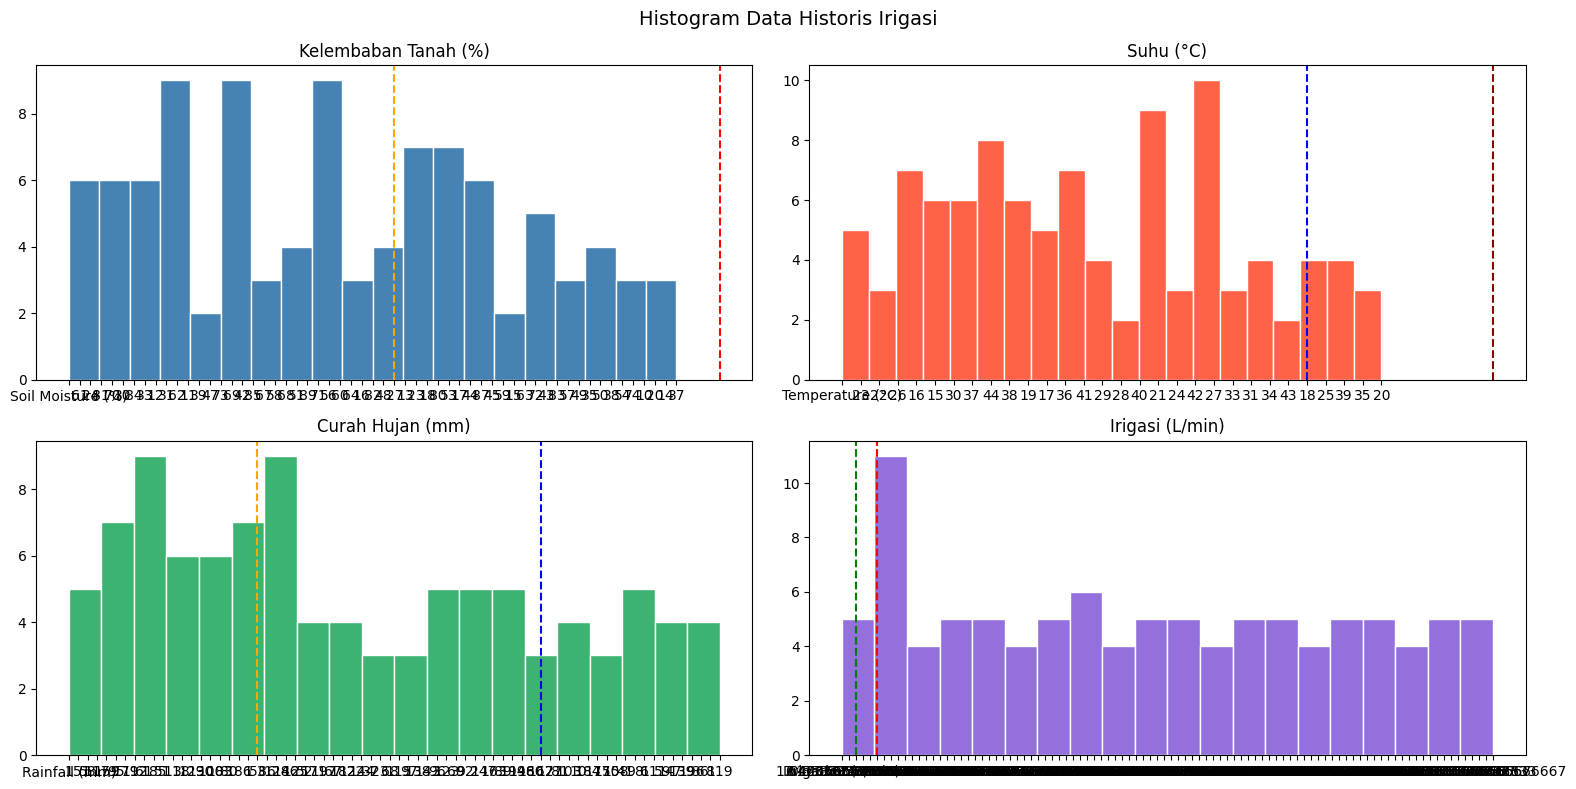

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Histogram Data Historis Irigasi', fontsize=14)

# Kelembaban
axes[0,0].hist(df['kelembaban'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].axvline(30, color='orange', linestyle='--')
axes[0,0].axvline(60, color='red', linestyle='--')
axes[0,0].set_title('Kelembaban Tanah (%)')

# Suhu
axes[0,1].hist(df['suhu'], bins=20, color='tomato', edgecolor='white')
axes[0,1].axvline(25, color='blue', linestyle='--')
axes[0,1].axvline(35, color='darkred', linestyle='--', label='35°C')
axes[0,1].set_title('Suhu (°C)')

# Curah Hujan
axes[1,0].hist(df['curah_hujan'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1,0].axvline(20, color='orange', linestyle='--', label='20mm')
axes[1,0].axvline(50, color='blue', linestyle='--', label='50mm')
axes[1,0].set_title('Curah Hujan (mm)')

# Irigasi
axes[1,1].hist(df['irigasi'], bins=20, color='mediumpurple', edgecolor='white')
axes[1,1].axvline(2, color='green', linestyle='--')
axes[1,1].axvline(5, color='red', linestyle='--')

plt.tight_layout()
plt.show()

## 3. Definisi Fungsi Keanggotaan

In [28]:
# Definisi variabel fuzzy
kelembaban  = ctrl.Antecedent(np.arange(0, 101, 1), 'kelembaban')
suhu        = ctrl.Antecedent(np.arange(10, 51, 1), 'suhu')
hujan       = ctrl.Antecedent(np.arange(0, 201, 1), 'curah_hujan')
irigasi     = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'irigasi')

# Kelembaban: Rendah 0-40, Sedang 30-70, Tinggi 60-100
kelembaban['rendah'] = fuzz.trimf(kelembaban.universe, [0, 0, 40])
kelembaban['sedang'] = fuzz.trimf(kelembaban.universe, [30, 50, 70])
kelembaban['tinggi'] = fuzz.trimf(kelembaban.universe, [60, 100, 100])

# Suhu: Dingin 10-25, Sedang 20-35, Panas 30-50
suhu['dingin'] = fuzz.trimf(suhu.universe, [10, 10, 25])
suhu['sedang'] = fuzz.trimf(suhu.universe, [20, 27, 35])
suhu['panas']  = fuzz.trimf(suhu.universe, [30, 50, 50])

# Curah Hujan: Tidak Ada 0-20, Ringan 10-50, Deras 50-200
hujan['tidak_ada'] = fuzz.trimf(hujan.universe, [0, 0, 20])
hujan['ringan']    = fuzz.trimf(hujan.universe, [10, 30, 50])
hujan['deras']     = fuzz.trimf(hujan.universe, [50, 200, 200])

# Irigasi: Rendah 0-3, Sedang 2-6, Tinggi 5-10
irigasi['rendah'] = fuzz.trimf(irigasi.universe, [0, 0, 3])
irigasi['sedang'] = fuzz.trimf(irigasi.universe, [2, 4, 6])
irigasi['tinggi'] = fuzz.trimf(irigasi.universe, [5, 10, 10])

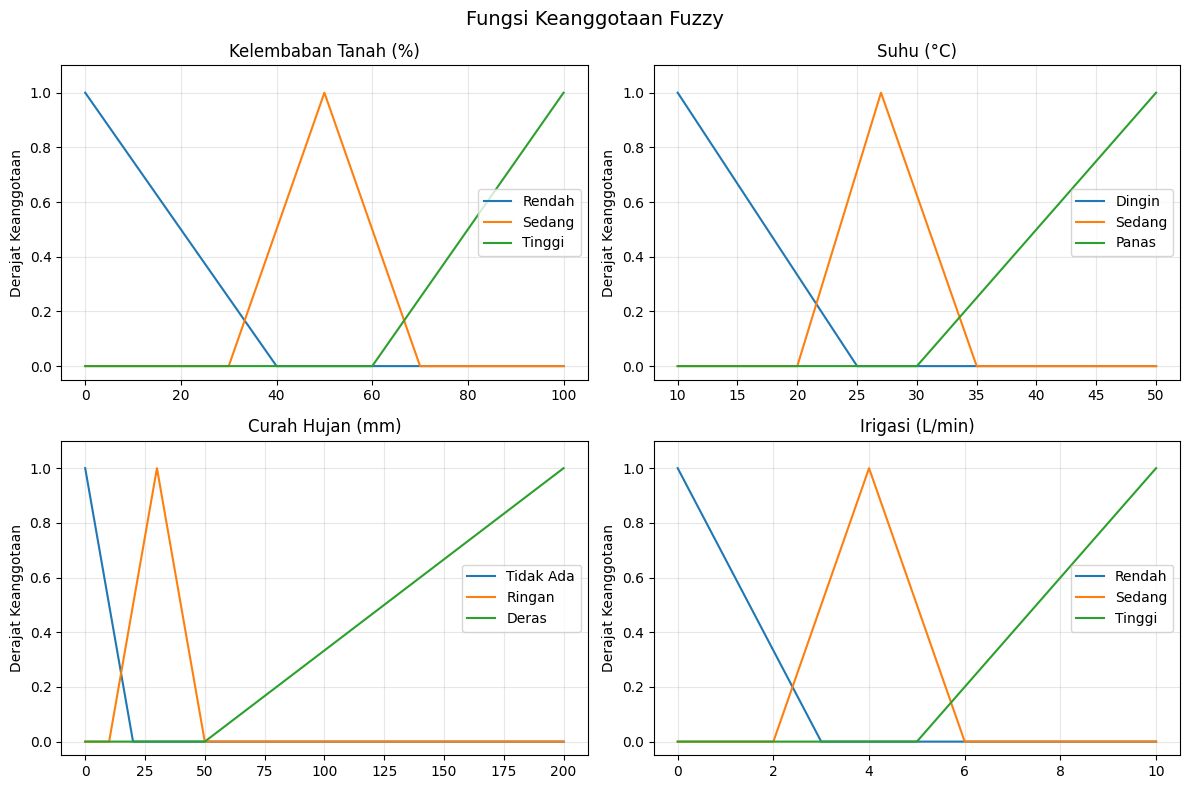

In [29]:
# Visualisasi fungsi keanggotaan
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Fungsi Keanggotaan Fuzzy', fontsize=14)

x_k = kelembaban.universe
axes[0,0].plot(x_k, fuzz.trimf(x_k, [0,0,40]),     label='Rendah')
axes[0,0].plot(x_k, fuzz.trimf(x_k, [30,50,70]),   label='Sedang')
axes[0,0].plot(x_k, fuzz.trimf(x_k, [60,100,100]), label='Tinggi')
axes[0,0].set_title('Kelembaban Tanah (%)')
axes[0,0].legend()

x_s = suhu.universe
axes[0,1].plot(x_s, fuzz.trimf(x_s, [10,10,25]), label='Dingin')
axes[0,1].plot(x_s, fuzz.trimf(x_s, [20,27,35]), label='Sedang')
axes[0,1].plot(x_s, fuzz.trimf(x_s, [30,50,50]), label='Panas')
axes[0,1].set_title('Suhu (°C)')
axes[0,1].legend()

x_h = hujan.universe
axes[1,0].plot(x_h, fuzz.trimf(x_h, [0,0,20]),     label='Tidak Ada')
axes[1,0].plot(x_h, fuzz.trimf(x_h, [10,30,50]),   label='Ringan')
axes[1,0].plot(x_h, fuzz.trimf(x_h, [50,200,200]), label='Deras')
axes[1,0].set_title('Curah Hujan (mm)')
axes[1,0].legend()

x_i = irigasi.universe
axes[1,1].plot(x_i, fuzz.trimf(x_i, [0,0,3]),   label='Rendah')
axes[1,1].plot(x_i, fuzz.trimf(x_i, [2,4,6]),   label='Sedang')
axes[1,1].plot(x_i, fuzz.trimf(x_i, [5,10,10]), label='Tinggi')
axes[1,1].set_title('Irigasi (L/min)')
axes[1,1].legend()

for ax in axes.flat:
    ax.set_ylim(-0.05, 1.1)
    ax.grid(alpha=0.3)
    ax.set_ylabel('Derajat Keanggotaan')

plt.tight_layout()
plt.show()

## 4. Implementasi Inferensi Fuzzy Mamdani

In [30]:
# Rule base
rule1 = ctrl.Rule(kelembaban['rendah'] & suhu['panas']  & hujan['tidak_ada'], irigasi['tinggi'])
rule2 = ctrl.Rule(kelembaban['sedang'] & suhu['sedang'] & hujan['ringan'],    irigasi['sedang'])
rule3 = ctrl.Rule(kelembaban['tinggi'] & suhu['dingin'] & hujan['deras'],     irigasi['rendah'])
rule4 = ctrl.Rule(kelembaban['rendah'] & suhu['dingin'] & hujan['tidak_ada'], irigasi['sedang'])
rule5 = ctrl.Rule(kelembaban['tinggi'] & suhu['panas']  & hujan['deras'],     irigasi['rendah'])

sistem = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
sim    = ctrl.ControlSystemSimulation(sistem)

print("Sistem fuzzy berhasil dibuat dengan 5 rule.")

Sistem fuzzy berhasil dibuat dengan 5 rule.


## 5. Evaluasi Sistem

In [31]:
def prediksi(k, s, h):
    sim.input['kelembaban']  = k
    sim.input['suhu']        = s
    sim.input['curah_hujan'] = h
    sim.compute()
    return sim.output['irigasi']

test_cases = [
    (20, 42,   0, "Kering & Panas (Kasus A)"),
    (80, 20, 100, "Basah & Dingin (Kasus B)"),
    (50, 27,  30, "Kondisi Normal"),
    (10, 45,   5, "Sangat Kering & Panas"),
]

print(f"{'Kondisi':<30} {'Kelembaban':>10} {'Suhu':>6} {'Hujan':>7} {'Irigasi':>10}")
print("-" * 70)
for k, s, h, label in test_cases:
    out = prediksi(k, s, h)
    print(f"{label:<30} {k:>9}% {s:>5}°C {h:>6}mm {out:>9.3f} L/min")

Kondisi                        Kelembaban   Suhu   Hujan    Irigasi
----------------------------------------------------------------------
Kering & Panas (Kasus A)              20%    42°C      0mm     8.056 L/min
Basah & Dingin (Kasus B)              80%    20°C    100mm     1.267 L/min
Kondisi Normal                        50%    27°C     30mm     4.000 L/min
Sangat Kering & Panas                 10%    45°C      5mm     8.250 L/min


## 6. Pertanyaan

### Q1: Bagaimana perubahan kelembaban tanah mempengaruhi keluaran irigasi?

In [32]:
k_range = np.arange(5, 96, 5)
outputs = [prediksi(k, 35, 10) for k in k_range]

plt.figure(figsize=(9, 4))
plt.plot(k_range, outputs, 'o-', color='steelblue')
plt.xlabel('Kelembaban Tanah (%)')
plt.ylabel('Irigasi (L/min)')
plt.title('Pengaruh Kelembaban terhadap Output Irigasi (Suhu=35°C, Hujan=10mm)')
plt.grid(alpha=0.3)
plt.show()

print("""
Perubahan kelembaban tanah berbanding terbalik dengan output irigasi.
Semakin rendah kelembaban, semakin besar debit irigasi yang direkomendasikan.
Ketika kelembaban sudah tinggi (>60%), sistem otomatis menekan irigasi ke level rendah
untuk menghindari over-watering.
""")

KeyError: 'irigasi'

### Q2: Apa yang terjadi ketika curah hujan meningkat?

In [ ]:
h_range  = np.arange(0, 181, 10)
outputs_h = [prediksi(35, 35, h) for h in h_range]

plt.figure(figsize=(9, 4))
plt.plot(h_range, outputs_h, 's-', color='mediumseagreen')
plt.xlabel('Curah Hujan (mm)')
plt.ylabel('Irigasi (L/min)')
plt.title('Pengaruh Curah Hujan terhadap Output Irigasi (Kelembaban=35%, Suhu=35°C)')
plt.grid(alpha=0.3)
plt.show()

print("""
Ketika curah hujan meningkat, output irigasi akan turun.
Pada rule 3 dan 5, kondisi hujan deras akan memaksa output menjadi rendah
karena kebutuhan air sudah terpenuhi secara alami.
""")

### Q3: Bandingkan dua kasus uji dan jelaskan perbedaan hasilnya

In [ ]:
out_a = prediksi(15, 42, 0)
out_b = prediksi(80, 20, 100)

print(f"Kasus A (Kering & Panas): Kelembaban=15%, Suhu=42°C, Hujan=0mm")
print(f"  → Irigasi: {out_a:.3f} L/min")
print()
print(f"Kasus B (Basah & Dingin): Kelembaban=80%, Suhu=20°C, Hujan=100mm")
print(f"  → Irigasi: {out_b:.3f} L/min")
print("""
Kasus A menghasilkan irigasi tinggi karena ketiga kondisi input mengarah pada
kebutuhan air yang besar: tanah kering, suhu panas, dan tidak ada hujan.
Rule 1 aktif dengan kekuatan penuh.

Kasus B menghasilkan irigasi rendah karena tanah sudah jenuh, suhu rendah
sehingga penguapan lambat, dan hujan deras sudah menyuplai air secara alami.
Rule 3 dan 5 aktif, keduanya menghasilkan irigasi rendah.
""")

### Q4: Modifikasi aturan fuzzy untuk meningkatkan sistem

In [ ]:
# Tambah 2 rule baru untuk meningkatkan coverage
# Rule 6: kelembaban sedang + suhu panas + hujan tidak ada → irigasi tinggi
# Rule 7: kelembaban rendah + hujan ringan → irigasi sedang
rule6 = ctrl.Rule(kelembaban['sedang'] & suhu['panas'] & hujan['tidak_ada'], irigasi['tinggi'])
rule7 = ctrl.Rule(kelembaban['rendah'] & hujan['ringan'], irigasi['sedang'])

sistem_mod = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
sim_mod    = ctrl.ControlSystemSimulation(sistem_mod)

def prediksi_mod(k, s, h):
    sim_mod.input['kelembaban']  = k
    sim_mod.input['suhu']        = s
    sim_mod.input['curah_hujan'] = h
    sim_mod.compute()
    return sim_mod.output['irigasi']

print(f"{'Kondisi':<25} {'Asli':>10} {'Modifikasi':>12}")
print("-" * 50)
for k, s, h, label in test_cases:
    out_asli = prediksi(k, s, h)
    out_mod  = prediksi_mod(k, s, h)
    print(f"{label:<25} {out_asli:>9.3f}  {out_mod:>10.3f}")

print("""
Penambahan rule 6 dan 7 membuat sistem lebih responsif pada kondisi
yang sebelumnya tidak ter-cover dengan baik, terutama pada kondisi
kelembaban sedang dengan suhu panas tanpa hujan.
""")